In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def importeer_schone_data(bestandsnaam, kolommen_lijst):
    """
    Leest het databestand in, skipt de metadata en geeft de kolommen namen.
    """
    # sep='\s+' herkent één of meerdere spaties als scheidingsteken
    # skiprows=5 slaat de eerste 5 regels uit het .txt bestand over
    # header=None zorgt ervoor dat de eerste datarij (rij 6) niet als titel wordt gebruikt
    df = pd.read_csv(bestandsnaam, sep='\s+', skiprows=5, header=None)
    
    # Omdat we de originele titels hebben geskipt, geven we ze hier handmatig weer terug
    # Gebaseerd op regel 3, 4 en 5 uit jouw afbeelding:
    geselecteerde_df = df.iloc[:, kolommen_lijst]
    df.columns = ['Time_s', 'element_1_m', 'element_2_m', 'element_3_m', 'element_5_m', 'element_6_m']
    
    return geselecteerde_df, df.columns

importeer_schone_data(r"Data\SWL-2%-CS1-Test-2\2026-3-4 SWL Berm 2% - Test 2.experiment - 150% (4).txt", [0])


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\929952\AppData\Local\Temp\ipykernel_19292\2358841037.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(bestandsnaam, sep='\s+', skiprows=5, header=None)


(                  0
 0          0.000000
 1          0.007812
 2          0.015625
 3          0.023438
 4          0.031250
 ...             ...
 261240  2040.940000
 261241  2040.950000
 261242  2040.950000
 261243  2040.960000
 261244  2040.970000
 
 [261245 rows x 1 columns],
 Index(['Time_s', 'element_1_m', 'element_2_m', 'element_3_m', 'element_5_m',
        'element_6_m'],
       dtype='str'))

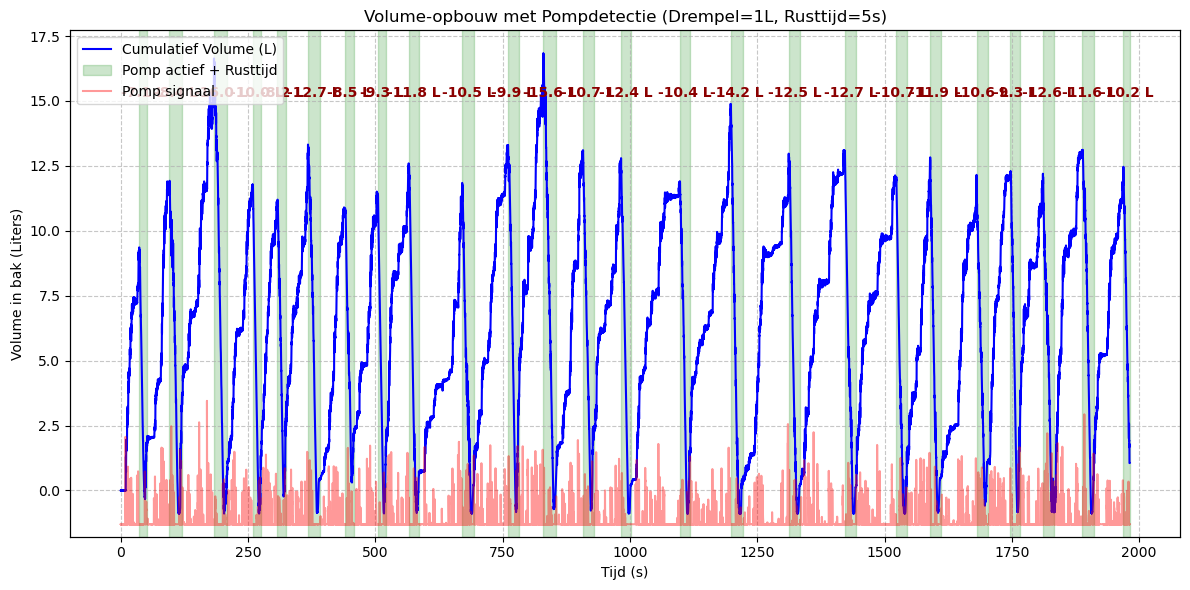

--> Functie gereed. Er zijn 25 pompmomenten gedetecteerd (>1L).
--> Totaal overgeslagen volume (met pompcorrectie van +277.8L): 278.81 Liter


In [73]:
#Overtopping box to volumes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data,alles = importeer_schone_data(r"Data\SWL-2%-CS1-Test-3\2026-3-5 SWL Berm 2% - Test 3.experiment - 140% (4).txt", [0,4,5])

def bereken_bak_volume_pomp(data, T_golf, pomp_drempel_L, rusttijd_s):
    """
    Berekent het stapsgewijze volume in een bak, detecteert pompmomenten
    en plot tegelijkertijd een indicatief signaal (data[4]) aan de onderkant.
    """
    # --- Vaste parameters ---
    fs = 128           # [Hz] Vaste sampling rate
    lengte_bak = 0.37  # [m]
    breedte_bak = 0.22 # [m]
    
    oppervlakte_pomp = ((0.15/2)**2)*np.pi
    oppervlakte = lengte_bak * breedte_bak - oppervlakte_pomp

    # --- 1. Data inlezen (inclusief het signaal!) ---
    df = pd.DataFrame({
        'Tijd': data[0],
        'Waterstand': data[5],
        'Signaal': data[4]  # <-- Hier voegen we het extra signaal toe
    })
    
    # --- 2. Smoothing (1/4 golfperiode) ---
    window_size = int(0.25 * T_golf * fs)
    df['Waterstand_smooth'] = df['Waterstand'].rolling(window=window_size, center=True).mean().bfill().ffill()
    
    # --- 3. Volume Berekening ---
    df['Volume_L'] = (df['Waterstand_smooth'] - df['Waterstand_smooth'].iloc[0]) * oppervlakte * 1000 
    
    # --- 4. POMP DETECTIE ---
    window_pomp = int(1.5 * T_golf * fs)
    df['Volume_pomp_smooth'] = df['Volume_L'].rolling(window_pomp, center=True).mean().bfill().ffill()
    
    df['dV'] = df['Volume_pomp_smooth'].diff(fs).fillna(0)
    
    is_dropping = df['dV'] < -0.5 
    df['pump_group'] = (~is_dropping).cumsum()
    
    pump_events = []
    totale_pomp_correctie = 0
    
    for name, group in df[is_dropping].groupby('pump_group'):
        if len(group) == 0:
            continue
            
        idx_start = group.index[0]
        idx_end = group.index[-1]
        
        zoek_start = max(0, idx_start - 3 * fs)
        real_start_idx = df['Volume_pomp_smooth'].iloc[zoek_start:idx_start+1].idxmax()
        
        zoek_eind = min(len(df) - 1, idx_end + 3 * fs)
        real_end_idx_steep = df['Volume_pomp_smooth'].iloc[idx_end:zoek_eind+1].idxmin()
        
        idx_na_rust = min(len(df) - 1, real_end_idx_steep + int(rusttijd_s * fs))
        
        vol_start = df['Volume_pomp_smooth'].loc[real_start_idx]
        vol_na_rust = df['Volume_pomp_smooth'].loc[idx_na_rust]
        vol_drop = vol_start - vol_na_rust
        
        if vol_drop >= pomp_drempel_L:
            t_start = df['Tijd'].loc[real_start_idx]
            t_end = df['Tijd'].loc[idx_na_rust] 
            
            if pump_events and real_start_idx <= pump_events[-1]['end_idx']:
                 pump_events[-1]['end_idx'] = max(pump_events[-1]['end_idx'], idx_na_rust)
                 pump_events[-1]['t_end'] = df['Tijd'].loc[pump_events[-1]['end_idx']]
                 pump_events[-1]['drop'] = df['Volume_pomp_smooth'].loc[pump_events[-1]['start_idx']] - df['Volume_pomp_smooth'].loc[pump_events[-1]['end_idx']]
            else:
                pump_events.append({
                    'start_idx': real_start_idx,
                    'end_idx': idx_na_rust,
                    't_start': t_start,
                    't_end': t_end,
                    'drop': vol_drop
                })

    totale_pomp_correctie = sum(ev['drop'] for ev in pump_events)
    totaal_volume = df['Volume_L'].iloc[-1] + totale_pomp_correctie

    # --- 5. Visualisatie ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot het volume op de linkeras (ax1)
    ax1.plot(df['Tijd'], df['Volume_L'], label='Cumulatief Volume (L)', color='blue')
    
    # Kleur de pompmomenten in
    for i, event in enumerate(pump_events):
        label = 'Pomp actief + Rusttijd' if i == 0 else "" 
        ax1.axvspan(event['t_start'], event['t_end'], color='green', alpha=0.2, label=label)
        
        mid_t = (event['t_start'] + event['t_end']) / 2
        y_pos = df['Volume_L'].max() * 0.9
        ax1.text(mid_t, y_pos, f"-{event['drop']:.1f} L", color='darkred', ha='center', fontweight='bold')
    
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Volume in bak (Liters)')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- EXTRA SIGNAAL PLOTTEN (Rechteras) ---
    ax2 = ax1.twinx()  # Tweede as aanmaken
    ax2.plot(df['Tijd'], df['Signaal'], color="red", alpha=0.4, label='Pomp signaal')
    
    # Haal de getallen weg zodat het puur een indicatie is
    ax2.set_yticks([])
    
    # Push het signaal naar de bodem door de as bovenaan heeeel lang te maken
    sig_min = df['Signaal'].min()
    sig_max = df['Signaal'].max()
    sig_range = sig_max - sig_min if sig_max != sig_min else 1
    # Door er + (3 * sig_range) bij te doen, dwingen we de lijn naar de onderste ~25% van de grafiek
    ax2.set_ylim(sig_min - 0.1 * sig_range, sig_max + 3 * sig_range)

    # Legenda's samenvoegen
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.title(f'Volume-opbouw met Pompdetectie (Drempel={pomp_drempel_L}L, Rusttijd={rusttijd_s}s)')
    plt.tight_layout()
    plt.show()
    
    print(f"--> Functie gereed. Er zijn {len(pump_events)} pompmomenten gedetecteerd (>{pomp_drempel_L}L).")
    print(f"--> Totaal overgeslagen volume (met pompcorrectie van +{totale_pomp_correctie:.1f}L): {totaal_volume:.2f} Liter")
    
    return df, totaal_volume

# --- AANROEPEN ---
df_resultaten, totaal = bereken_bak_volume_pomp(data, T_golf=1, pomp_drempel_L=1, rusttijd_s=5)


--- METHODE 1: VOLUME VERSCHIL ---
Grootste toename over 1 golfperiode = 2.88 Liter
Dit gebeurde rond t = 118.7 seconden.

--- METHODE 2: SIGNAAL PIEKEN ---
Er zijn 199 losse overtopping momenten gedetecteerd in het signaal.
De grootste sprong rondom een signaal-piek = 3.02 Liter
Dit gebeurde rond t = 779.5 seconden.



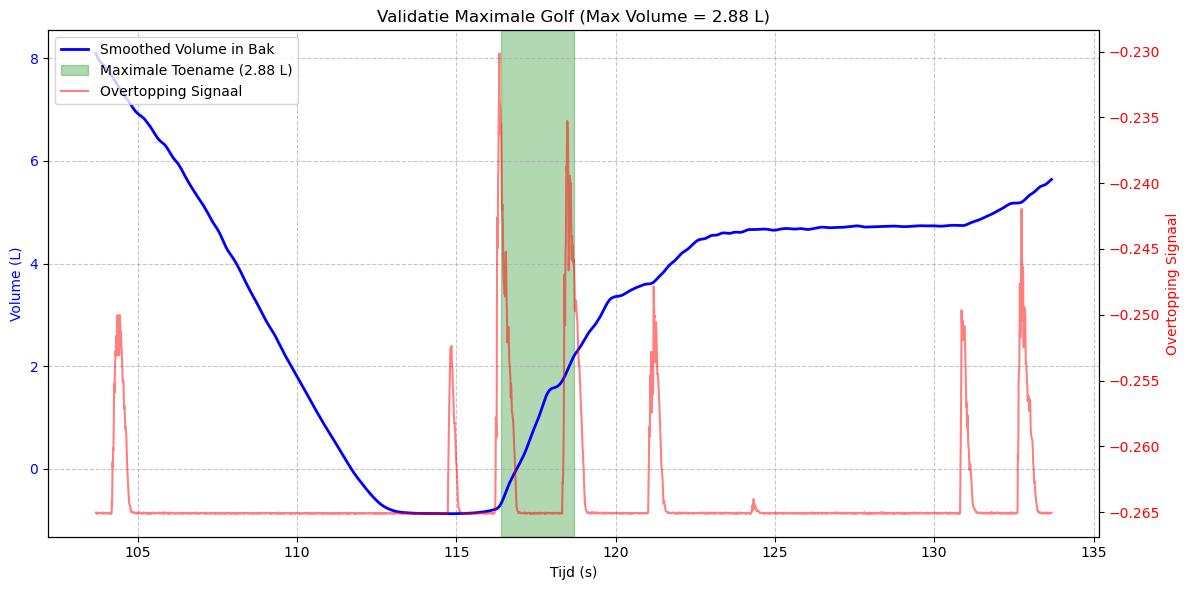

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def analyseer_maximale_golf(df, T_golf, fs=128):
    """
    Berekent het maximale overtopping volume van 1 golf via twee onafhankelijke methodes.
    """
    # Aantal meetpunten in exact 1 golfperiode
    window = int(T_golf * fs)
    
    # ---------------------------------------------------------
    # METHODE 1: Steilste toename in de bak
    # ---------------------------------------------------------
    # We berekenen het volumeverschil tussen 'nu' en '1 golfperiode geleden'.
    # We gebruiken Volume_pomp_smooth omdat deze al netjes gesmoothed is.
    df['dV_1_golf'] = df['Volume_pomp_smooth'].diff(periods=window)
    
    # Zoek de maximale sprong in het volume
    max_vol_1 = df['dV_1_golf'].max()
    idx_max_1 = df['dV_1_golf'].idxmax()
    tijd_max_1 = df.loc[idx_max_1, 'Tijd']
    
    print("--- METHODE 1: VOLUME VERSCHIL ---")
    print(f"Grootste toename over 1 golfperiode = {max_vol_1:.2f} Liter")
    print(f"Dit gebeurde rond t = {tijd_max_1:.1f} seconden.\n")
    
    # ---------------------------------------------------------
    # METHODE 2: Valideren via het overtopping signaal
    # ---------------------------------------------------------
    print("--- METHODE 2: SIGNAAL PIEKEN ---")
    # We bepalen een drempel voor het overtopping signaal (gemiddelde + 3x de standaardafwijking)
    # Dit zorgt ervoor dat we alleen de echte 'klappen' pakken.
    drempel = df['Signaal'].mean() + 3 * df['Signaal'].std() 
    
    # Zoek pieken die minstens 'window' samples uit elkaar liggen
    pieken_idx, _ = find_peaks(df['Signaal'], height=drempel, distance=window)
    
    golf_volumes = []
    piek_tijden = []
    
    for idx in pieken_idx:
        # We kijken 0.5 * T_golf vóór de klap, en 1.0 * T_golf na de klap
        idx_start = max(0, idx - int(0.5 * window))
        idx_eind = min(len(df)-1, idx + int(1.0 * window))
        
        vol_start = df['Volume_pomp_smooth'].iloc[idx_start]
        vol_eind = df['Volume_pomp_smooth'].iloc[idx_eind]
        
        # Alleen meenemen als we NIET aan het pompen zijn (volume moet stijgen)
        if vol_eind > vol_start:
            golf_volumes.append(vol_eind - vol_start)
            piek_tijden.append(df['Tijd'].iloc[idx])
            
    if len(golf_volumes) > 0:
        max_vol_2 = max(golf_volumes)
        idx_max_2 = np.argmax(golf_volumes)
        tijd_max_2 = piek_tijden[idx_max_2]
        
        print(f"Er zijn {len(golf_volumes)} losse overtopping momenten gedetecteerd in het signaal.")
        print(f"De grootste sprong rondom een signaal-piek = {max_vol_2:.2f} Liter")
        print(f"Dit gebeurde rond t = {tijd_max_2:.1f} seconden.\n")
    else:
        print("Geen duidelijke pieken gevonden in df['Signaal'] die leidden tot een toename.\n")
        
    # ---------------------------------------------------------
    # VISUALISATIE (Plotting van Methode 1)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 6))
    
    # We zoomen in op de tijdlijn: 15 seconden vóór en 15 seconden ná de maximale klap
    zoom_start = max(0, idx_max_1 - 15 * fs)
    zoom_eind = min(len(df)-1, idx_max_1 + 15 * fs)
    
    t_zoom = df['Tijd'].iloc[zoom_start:zoom_eind]
    v_zoom = df['Volume_pomp_smooth'].iloc[zoom_start:zoom_eind]
    sig_zoom = df['Signaal'].iloc[zoom_start:zoom_eind]
    
    # Linkeras: Volume
    ax1 = plt.gca()
    ax1.plot(t_zoom, v_zoom, label='Smoothed Volume in Bak', color='blue', linewidth=2)
    
    # Markeer de periode waarin de grootste golf is gedetecteerd
    t_start_sprong = df['Tijd'].iloc[max(0, idx_max_1 - window)]
    t_eind_sprong = df['Tijd'].iloc[idx_max_1]
    ax1.axvspan(t_start_sprong, t_eind_sprong, color='green', alpha=0.3, label=f'Maximale Toename ({max_vol_1:.2f} L)')
    
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Volume (L)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Rechteras: Signaal
    ax2 = ax1.twinx()
    ax2.plot(t_zoom, sig_zoom, color='red', alpha=0.5, label='Overtopping Signaal')
    ax2.set_ylabel('Overtopping Signaal', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Samenvoegen van de legendes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    plt.title(f'Validatie Maximale Golf (Max Volume = {max_vol_1:.2f} L)')
    plt.tight_layout()
    plt.show()
    
    return max_vol_1

# AANROEPEN (Vervang T_golf met jouw eigen T_m)
# Gebruik het dataframe df_resultaten uit je vorige script!
max_volume_van_1_golf = analyseer_maximale_golf(df_resultaten, T_golf=2.3, fs=128)

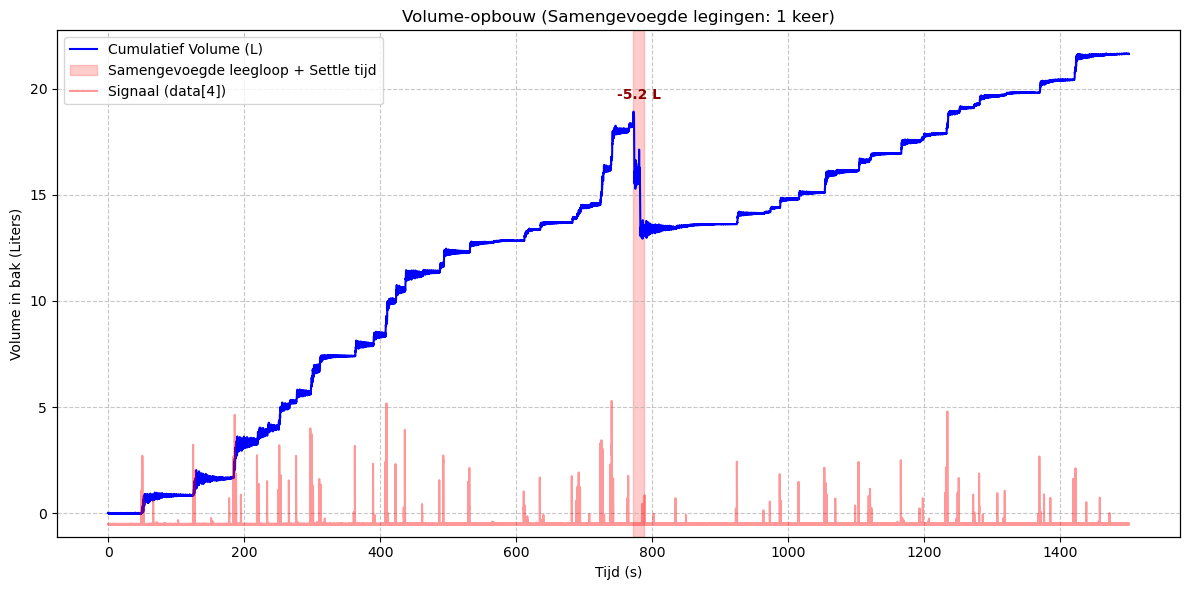

--> TOTAAL AANTAL SAMENGEVOEGDE LEGINGEN: 1
--> TOTAAL OVERGESLAGEN VOLUME: 26.83 Liter


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data1,alles = importeer_schone_data(r"Data\SWL-2%-CS1-Test-2\2026-3-4 SWL Berm 2% - Test 2.experiment - 80% (4).txt", [0,4,5])

def bereken_bak_volume_handmatig(data, T_golf, pomp_drempel_L, rusttijd_s, samenvoeg_tijd_s):
    """
    Berekent het stapsgewijze volume, detecteert handmatige leegloop,
    voegt extracties binnen 'samenvoeg_tijd_s' samen tot één actie,
    en wacht pas op het einde 'rusttijd_s' seconden om het werkelijke
    weggehaalde volume af te lezen. Inclusief indicatief signaal onderin.
    """
    # --- Vaste parameters ---
    fs = 128           
    lengte_bak = 0.365  
    breedte_bak = 0.268 
    oppervlakte = lengte_bak * breedte_bak

    # --- 1. Data inlezen (nu inclusief het signaal op index 4) ---
    df = pd.DataFrame({
        'Tijd': data[0],
        'Waterstand': data[5],
        'Signaal': data[4]  # <-- Toegevoegd signaal
    })
    
    # --- 2. Smoothing (1/4 golfperiode) ---
    window_size = int(0.25 * T_golf * fs)
    df['Waterstand_smooth'] = df['Waterstand'].rolling(window=window_size, center=True).mean().bfill().ffill()
    df['Volume_L'] = (df['Waterstand_smooth'] - df['Waterstand_smooth'].iloc[0]) * oppervlakte * 1000 
    
    # --- 3. POMP / HANDMATIG LEEGMAKEN DETECTIE ---
    window_pomp = int(1.5 * T_golf * fs)
    df['Volume_pomp_smooth'] = df['Volume_L'].rolling(window=window_pomp, center=True).mean().bfill().ffill()
    
    df['dV'] = df['Volume_pomp_smooth'].diff(fs).fillna(0)
    
    is_dropping = df['dV'] < -0.5 
    df['pump_group'] = (~is_dropping).cumsum()
    
    ruwe_events = []
    
    # Stap A: Verzamel alle losse, ruwe dalingen
    for name, group in df[is_dropping].groupby('pump_group'):
        if len(group) == 0:
            continue
            
        idx_start = group.index[0]
        idx_end = group.index[-1]
        
        # Lokale piek (start) en dal (einde van de steile beweging)
        zoek_start = max(0, idx_start - 3 * fs)
        real_start_idx = df['Volume_pomp_smooth'].iloc[zoek_start:idx_start+1].idxmax()
        
        zoek_eind = min(len(df) - 1, idx_end + 3 * fs)
        real_end_idx_steep = df['Volume_pomp_smooth'].iloc[idx_end:zoek_eind+1].idxmin()
        
        ruwe_events.append({
            'start_idx': real_start_idx,
            'end_idx': real_end_idx_steep,
            't_start': df['Tijd'].loc[real_start_idx],
            't_end': df['Tijd'].loc[real_end_idx_steep]
        })

    # Stap B: Voeg dalingen samen die binnen de samenvoeg_tijd (7s) vallen
    gecombineerde_events = []
    
    for ev in ruwe_events:
        if not gecombineerde_events:
            gecombineerde_events.append(ev.copy())
        else:
            vorige_ev = gecombineerde_events[-1]
            tijd_verschil = ev['t_start'] - vorige_ev['t_end']
            
            # Als de daling snel genoeg volgt op de vorige, plakken we ze aan elkaar
            if tijd_verschil <= samenvoeg_tijd_s:
                vorige_ev['end_idx'] = ev['end_idx']
                vorige_ev['t_end'] = ev['t_end']
            else:
                gecombineerde_events.append(ev.copy())

    # Stap C: Voeg de rusttijd toe aan het EINDE van elk samengevoegd blok en bereken volume
    pump_events = []
    for ev in gecombineerde_events:
        # Voeg rusttijd toe ná de allerlaatste extractie van dit blok
        idx_na_rust = min(len(df) - 1, ev['end_idx'] + int(rusttijd_s * fs))
        
        vol_start = df['Volume_pomp_smooth'].loc[ev['start_idx']]
        vol_na_rust = df['Volume_pomp_smooth'].loc[idx_na_rust]
        vol_drop = vol_start - vol_na_rust
        
        if vol_drop >= pomp_drempel_L:
            pump_events.append({
                'start_idx': ev['start_idx'],
                'end_idx': idx_na_rust, # We overschrijven het eindpunt inclusief rusttijd voor de plot
                't_start': ev['t_start'],
                't_end': df['Tijd'].loc[idx_na_rust], # De rode strook loopt dus door tot NA de rusttijd
                'drop': vol_drop
            })

    # Totalen berekenen
    totale_pomp_correctie = sum(ev['drop'] for ev in pump_events)
    aantal_legingen = len(pump_events)
    
    # --- 4. Totaal Volume Berekenen ---
    totaal_volume = df['Volume_L'].iloc[-1] + totale_pomp_correctie

    # --- 5. Visualisatie ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot het volume op de linkeras (ax1)
    ax1.plot(df['Tijd'], df['Volume_L'], label='Cumulatief Volume (L)', color='blue')
    
    for i, event in enumerate(pump_events):
        label = 'Samengevoegde leegloop + Settle tijd' if i == 0 else "" 
        ax1.axvspan(event['t_start'], event['t_end'], color='red', alpha=0.2, label=label)
        
        mid_t = (event['t_start'] + event['t_end']) / 2
        y_pos = df['Volume_L'].max() * 0.9
        ax1.text(mid_t, y_pos, f"-{event['drop']:.1f} L", color='darkred', ha='center', fontweight='bold')
    
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Volume in bak (Liters)')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- EXTRA SIGNAAL PLOTTEN (Rechteras) ---
    ax2 = ax1.twinx()  # Tweede as aanmaken
    ax2.plot(df['Tijd'], df['Signaal'], color="red", alpha=0.4, label='Signaal (data[4])')
    
    # Haal de getallen weg zodat het puur een indicatie is
    ax2.set_yticks([])
    
    # Push het signaal naar de bodem door de as bovenaan heeeel lang te maken
    sig_min = df['Signaal'].min()
    sig_max = df['Signaal'].max()
    sig_range = sig_max - sig_min if sig_max != sig_min else 1
    # Door er + (3 * sig_range) bij te doen, dwingen we de lijn naar de onderste ~25% van de grafiek
    ax2.set_ylim(sig_min - 0.1 * sig_range, sig_max + 3 * sig_range)

    # Legenda's samenvoegen
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.title(f'Volume-opbouw (Samengevoegde legingen: {aantal_legingen} keer)')
    plt.tight_layout()
    plt.show()

    print(f"--> TOTAAL AANTAL SAMENGEVOEGDE LEGINGEN: {aantal_legingen}")
    print(f"--> TOTAAL OVERGESLAGEN VOLUME: {totaal_volume:.2f} Liter")
    
    return df, totaal_volume, aantal_legingen

df_result, eind_volume, legingen = bereken_bak_volume_handmatig(
    data1, 
    T_golf=1.5, 
    pomp_drempel_L=4, 
    rusttijd_s=3, 
    samenvoeg_tijd_s=7
)

In [66]:
import numpy as np

def bereken_golflengte(T, h, g=9.81):
    """
    Berekent de golflengte L iteratief met de dispersierelatie.
    T = Golfperiode (s)
    h = Waterdiepte (m)
    """
    # 1. Startwaarde: Diep-water golflengte (L0)
    L_oud = (g * T**2) / (2 * np.pi)
    
    # 2. Itereren tot het antwoord niet meer verandert
    tolerantie = 0.001
    verschil = 1.0
    
    while verschil > tolerantie:
        # Bereken de nieuwe L met de dispersierelatie
        L_nieuw = ((g * T**2) / (2 * np.pi)) * np.tanh((2 * np.pi * h) / L_oud)
        
        # Check hoe groot het verschil is
        verschil = abs(L_nieuw - L_oud)
        L_oud = L_nieuw
        
    return L_nieuw

# Voorbeeld:
periode = 1.766  # s
diepte = 0.365   # m
lengte = bereken_golflengte(periode, diepte)

print(f"De berekende golflengte is {lengte:.2f} meter.")

De berekende golflengte is 3.08 meter.
